In [1]:
# 🔹 Celda 1: Importar + Explicación

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

print("=" * 60)
print("SEMANA 3: CÁLCULO + GRADIENTES")
print("=" * 60)

print("""
¿POR QUÉ CÁLCULO EN ML?

En ML, queremos minimizar una función de pérdida (loss):
  L(w) = error de predicción

El GRADIENTE nos dice:
  - En qué dirección ir para bajar
  - Cuán rápido bajar (magnitud)

Usaremos GRADIENT DESCENT para entrenar modelos.
""")


SEMANA 3: CÁLCULO + GRADIENTES

¿POR QUÉ CÁLCULO EN ML?

En ML, queremos minimizar una función de pérdida (loss):
  L(w) = error de predicción

El GRADIENTE nos dice:
  - En qué dirección ir para bajar
  - Cuán rápido bajar (magnitud)

Usaremos GRADIENT DESCENT para entrenar modelos.




1️⃣ DERIVADAS (TASA DE CAMBIO)

En x = 3.0:
Derivada analítica: f'(3.0) = 6.0
Derivada numérica: f'(3.0) ≈ 6.000000
Error: 3.93e-11


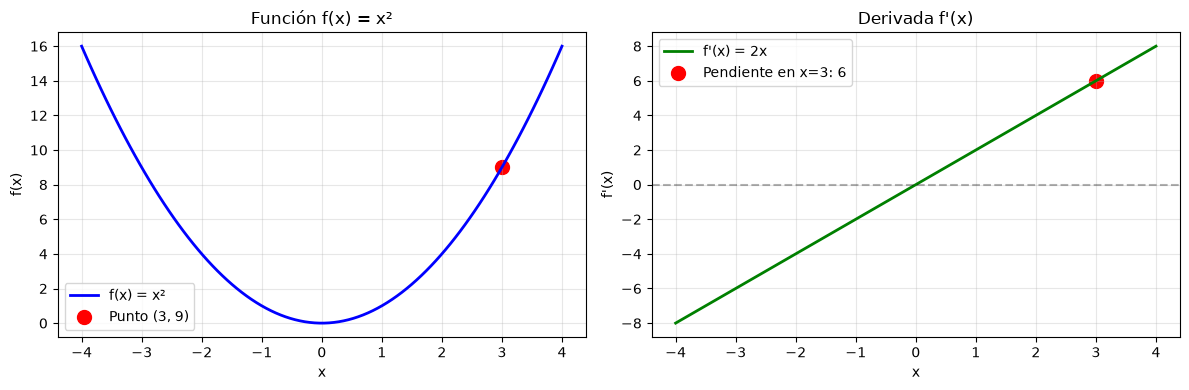


💡 INTERPRETACIÓN:
La derivada f'(x) = 2x es la PENDIENTE
Si f'(3) = 6: la función sube rápido en x=3
Si f'(0) = 0: mínimo (punto crítico)


In [2]:
# 🔹 Celda 2: Derivadas Simples

print("\n" + "=" * 60)
print("1️⃣ DERIVADAS (TASA DE CAMBIO)")
print("=" * 60)

# Función simple: f(x) = x²
def f(x):
    return x**2

# Derivada analítica: f'(x) = 2x
def f_prime(x):
    return 2 * x

# Derivada numérica (aproximación)
def numerical_derivative(f, x, h=1e-5):
    return (f(x + h) - f(x - h)) / (2 * h)

# Comparar
x = 3.0
print(f"\nEn x = {x}:")
print(f"Derivada analítica: f'({x}) = {f_prime(x)}")
print(f"Derivada numérica: f'({x}) ≈ {numerical_derivative(f, x):.6f}")
print(f"Error: {abs(f_prime(x) - numerical_derivative(f, x)):.2e}")

# Visualizar
x_vals = np.linspace(-4, 4, 100)
y_vals = f(x_vals)
y_prime_vals = f_prime(x_vals)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Función
ax1.plot(x_vals, y_vals, 'b-', linewidth=2, label='f(x) = x²')
ax1.scatter([3], [f(3)], color='red', s=100, label='Punto (3, 9)')
ax1.set_title('Función f(x) = x²')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_xlabel('x')
ax1.set_ylabel('f(x)')

# Derivada
ax2.plot(x_vals, y_prime_vals, 'g-', linewidth=2, label="f'(x) = 2x")
ax2.scatter([3], [f_prime(3)], color='red', s=100, label='Pendiente en x=3: 6')
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax2.set_title('Derivada f\'(x)')
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.set_xlabel('x')
ax2.set_ylabel("f'(x)")

plt.tight_layout()
plt.show()

print("\n💡 INTERPRETACIÓN:")
print("La derivada f'(x) = 2x es la PENDIENTE")
print("Si f'(3) = 6: la función sube rápido en x=3")
print("Si f'(0) = 0: mínimo (punto crítico)")



2️⃣ GRADIENTES (EN MÚLTIPLES VARIABLES)

En (x=2.0, y=3.0):
Gradiente analítico: ∇f = [4. 6.]
Gradiente numérico:  ∇f ≈ [4. 6.]
Error: 4.72e-11


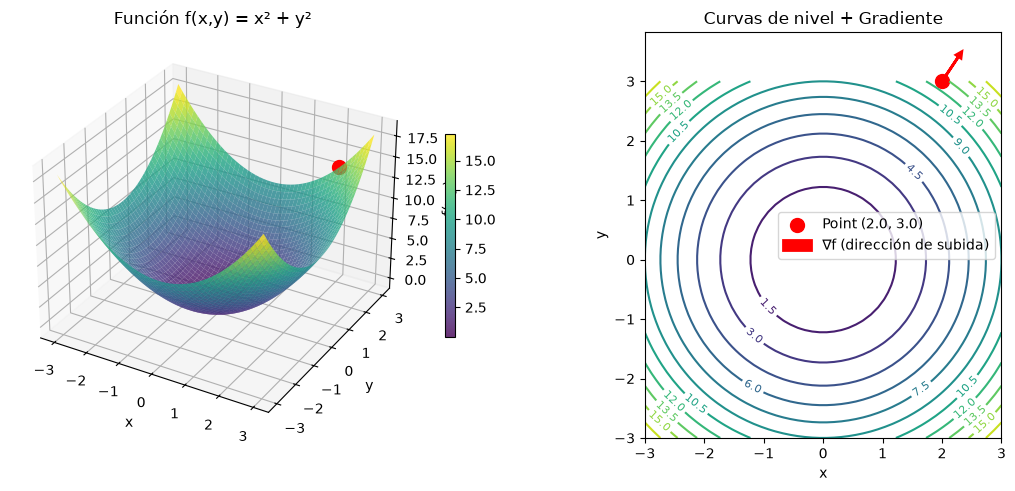


💡 INTERPRETACIÓN DEL GRADIENTE:
∇f = [2x, 2y] apunta en la DIRECCIÓN DE MÁXIMO CRECIMIENTO
Para MINIMIZAR, vamos en dirección OPUESTA: -∇f
En punto (2.0, 3.0), -∇f = [-4. -6.]


In [3]:
# 🔹 Celda 3: Gradientes (Multivariable)

print("\n" + "=" * 60)
print("2️⃣ GRADIENTES (EN MÚLTIPLES VARIABLES)")
print("=" * 60)

# Función 2D: f(x, y) = x² + y²
def f_2d(x, y):
    return x**2 + y**2

# Gradiente analítico: ∇f = [∂f/∂x, ∂f/∂y] = [2x, 2y]
def grad_f_2d(x, y):
    return np.array([2*x, 2*y])

# Gradiente numérico
def numerical_gradient_2d(f, x, y, h=1e-5):
    fx_plus = f(x + h, y)
    fx_minus = f(x - h, y)
    fy_plus = f(x, y + h)
    fy_minus = f(x, y - h)
    
    dfdx = (fx_plus - fx_minus) / (2 * h)
    dfdy = (fy_plus - fy_minus) / (2 * h)
    
    return np.array([dfdx, dfdy])

# Test
x, y = 2.0, 3.0
grad_analytic = grad_f_2d(x, y)
grad_numeric = numerical_gradient_2d(f_2d, x, y)

print(f"\nEn (x={x}, y={y}):")
print(f"Gradiente analítico: ∇f = {grad_analytic}")
print(f"Gradiente numérico:  ∇f ≈ {grad_numeric}")
print(f"Error: {np.linalg.norm(grad_analytic - grad_numeric):.2e}")

# Visualizar surface
fig = plt.figure(figsize=(12, 5))

# 3D Surface
ax1 = fig.add_subplot(121, projection='3d')
x_range = np.linspace(-3, 3, 50)
y_range = np.linspace(-3, 3, 50)
X, Y = np.meshgrid(x_range, y_range)
Z = f_2d(X, Y)

surf = ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax1.scatter([x], [y], [f_2d(x, y)], color='red', s=100, label=f'Point ({x}, {y})')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('f(x,y)')
ax1.set_title('Función f(x,y) = x² + y²')
plt.colorbar(surf, ax=ax1, shrink=0.5)

# Contour + Gradient vectors
ax2 = fig.add_subplot(122)
contour = ax2.contour(X, Y, Z, levels=15)
ax2.clabel(contour, inline=True, fontsize=8)
ax2.scatter([x], [y], color='red', s=100, label=f'Point ({x}, {y})')

# Dibujar vector gradiente
grad = grad_f_2d(x, y)
grad_normalized = grad / np.linalg.norm(grad)  # Normalizar para visualizar
ax2.arrow(x, y, grad_normalized[0]*0.5, grad_normalized[1]*0.5, 
          head_width=0.1, head_length=0.1, fc='red', ec='red', linewidth=2, 
          label='∇f (dirección de subida)')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Curvas de nivel + Gradiente')
ax2.legend()
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

print("\n💡 INTERPRETACIÓN DEL GRADIENTE:")
print("∇f = [2x, 2y] apunta en la DIRECCIÓN DE MÁXIMO CRECIMIENTO")
print("Para MINIMIZAR, vamos en dirección OPUESTA: -∇f")
print(f"En punto ({x}, {y}), -∇f = {-grad_analytic}")


2️⃣ GRADIENTES (EN MÚLTIPLES VARIABLES)

En (x=2.0, y=3.0):
Gradiente analítico: ∇f = [4. 6.]
Gradiente numérico:  ∇f ≈ [4. 6.]
Error: 4.72e-11


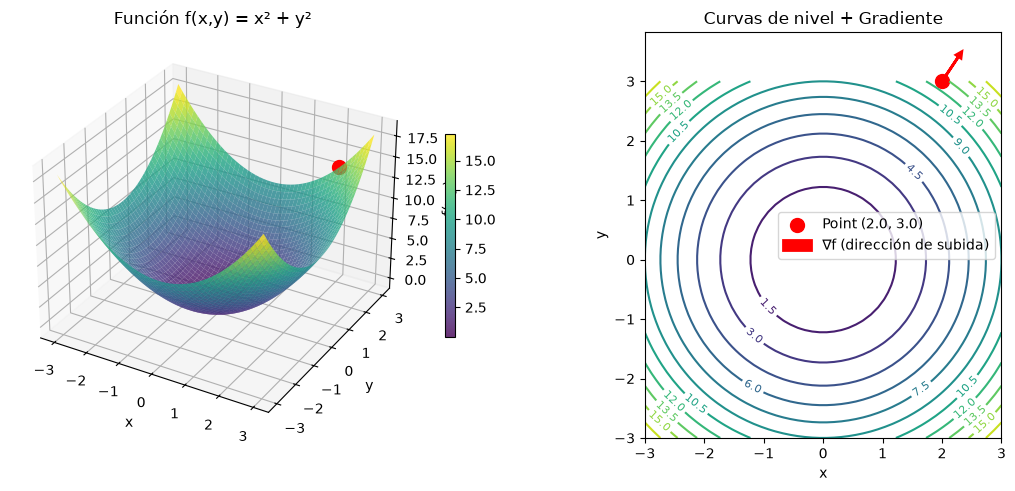


💡 INTERPRETACIÓN DEL GRADIENTE:
∇f = [2x, 2y] apunta en la DIRECCIÓN DE MÁXIMO CRECIMIENTO
Para MINIMIZAR, vamos en dirección OPUESTA: -∇f
En punto (2.0, 3.0), -∇f = [-4. -6.]


In [4]:
# print("\n" + "=" * 60)
print("2️⃣ GRADIENTES (EN MÚLTIPLES VARIABLES)")
print("=" * 60)

# Función 2D: f(x, y) = x² + y²
def f_2d(x, y):
    return x**2 + y**2

# Gradiente analítico: ∇f = [∂f/∂x, ∂f/∂y] = [2x, 2y]
def grad_f_2d(x, y):
    return np.array([2*x, 2*y])

# Gradiente numérico
def numerical_gradient_2d(f, x, y, h=1e-5):
    fx_plus = f(x + h, y)
    fx_minus = f(x - h, y)
    fy_plus = f(x, y + h)
    fy_minus = f(x, y - h)
    
    dfdx = (fx_plus - fx_minus) / (2 * h)
    dfdy = (fy_plus - fy_minus) / (2 * h)
    
    return np.array([dfdx, dfdy])

# Test
x, y = 2.0, 3.0
grad_analytic = grad_f_2d(x, y)
grad_numeric = numerical_gradient_2d(f_2d, x, y)

print(f"\nEn (x={x}, y={y}):")
print(f"Gradiente analítico: ∇f = {grad_analytic}")
print(f"Gradiente numérico:  ∇f ≈ {grad_numeric}")
print(f"Error: {np.linalg.norm(grad_analytic - grad_numeric):.2e}")

# Visualizar surface
fig = plt.figure(figsize=(12, 5))

# 3D Surface
ax1 = fig.add_subplot(121, projection='3d')
x_range = np.linspace(-3, 3, 50)
y_range = np.linspace(-3, 3, 50)
X, Y = np.meshgrid(x_range, y_range)
Z = f_2d(X, Y)

surf = ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax1.scatter([x], [y], [f_2d(x, y)], color='red', s=100, label=f'Point ({x}, {y})')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('f(x,y)')
ax1.set_title('Función f(x,y) = x² + y²')
plt.colorbar(surf, ax=ax1, shrink=0.5)

# Contour + Gradient vectors
ax2 = fig.add_subplot(122)
contour = ax2.contour(X, Y, Z, levels=15)
ax2.clabel(contour, inline=True, fontsize=8)
ax2.scatter([x], [y], color='red', s=100, label=f'Point ({x}, {y})')

# Dibujar vector gradiente
grad = grad_f_2d(x, y)
grad_normalized = grad / np.linalg.norm(grad)  # Normalizar para visualizar
ax2.arrow(x, y, grad_normalized[0]*0.5, grad_normalized[1]*0.5, 
          head_width=0.1, head_length=0.1, fc='red', ec='red', linewidth=2, 
          label='∇f (dirección de subida)')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Curvas de nivel + Gradiente')
ax2.legend()
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

print("\n💡 INTERPRETACIÓN DEL GRADIENTE:")
print("∇f = [2x, 2y] apunta en la DIRECCIÓN DE MÁXIMO CRECIMIENTO")
print("Para MINIMIZAR, vamos en dirección OPUESTA: -∇f")
print(f"En punto ({x}, {y}), -∇f = {-grad_analytic}")


In [5]:
# 🔹 Celda 5: Chain Rule (Crucial para ML)

print("\n" + "=" * 60)
print("4️⃣ CHAIN RULE (REGLA DE LA CADENA)")
print("=" * 60)

print("""
CHAIN RULE es CRÍTICO en deep learning (backpropagation).

Ejemplo: 
  z = (x²)² = x⁴
  
Derivada directa: dz/dx = 4x³

Con CHAIN RULE:
  z = u² donde u = x²
  dz/dx = (dz/du) * (du/dx) = 2u * 2x = 2(x²) * 2x = 4x³
""")

# Función compuesta: z = (x² + 1)²
def z_func(x):
    u = x**2 + 1
    z = u**2
    return z

# Chain rule: dz/dx = (dz/du) * (du/dx)
def z_derivative_chain_rule(x):
    u = x**2 + 1
    du_dx = 2*x
    dz_du = 2*u
    dz_dx = dz_du * du_dx
    return dz_dx, u, du_dx, dz_du

# Verificar con numérica
def numerical_deriv(f, x, h=1e-5):
    return (f(x+h) - f(x-h)) / (2*h)

x = 2.0
dz_dx_chain, u, du_dx, dz_du = z_derivative_chain_rule(x)
dz_dx_numeric = numerical_deriv(z_func, x)

print(f"\nEn x = {x}:")
print(f"u = x² + 1 = {u}")
print(f"du/dx = 2x = {du_dx}")
print(f"dz/du = 2u = {dz_du}")
print(f"dz/dx = (dz/du) * (du/dx) = {dz_du} * {du_dx} = {dz_dx_chain}")
print(f"\nVerificación numérica: {dz_dx_numeric:.6f}")
print(f"Error: {abs(dz_dx_chain - dz_dx_numeric):.2e}")

print("\n💡 EN DEEP LEARNING:")
print("La backpropagation es simplemente aplicar CHAIN RULE")
print("hacia atrás a través de la red neuronal.")



4️⃣ CHAIN RULE (REGLA DE LA CADENA)

CHAIN RULE es CRÍTICO en deep learning (backpropagation).

Ejemplo: 
  z = (x²)² = x⁴

Derivada directa: dz/dx = 4x³

Con CHAIN RULE:
  z = u² donde u = x²
  dz/dx = (dz/du) * (du/dx) = 2u * 2x = 2(x²) * 2x = 4x³


En x = 2.0:
u = x² + 1 = 5.0
du/dx = 2x = 4.0
dz/du = 2u = 10.0
dz/dx = (dz/du) * (du/dx) = 10.0 * 4.0 = 40.0

Verificación numérica: 40.000000
Error: 9.73e-10

💡 EN DEEP LEARNING:
La backpropagation es simplemente aplicar CHAIN RULE
hacia atrás a través de la red neuronal.



5️⃣ GRADIENT DESCENT EN 2D

Punto inicial: (3.0, 3.0), f = 18.0000
Punto final:   (0.0000, 0.0000), f = 0.0000


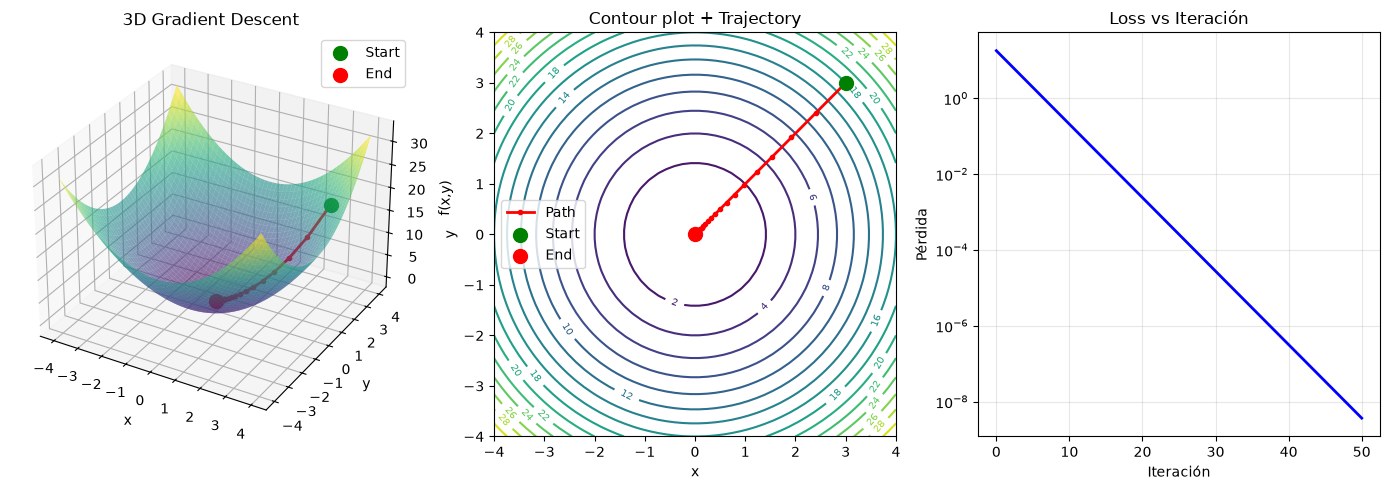


💡 OBSERVACIONES:
- Comienza en (3, 3)
- Gradiente apunta hacia el mínimo
- Cada paso mueve en dirección opuesta al gradiente
- Converge al mínimo (0, 0)


In [6]:
# 🔹 Celda 6: Descenso de Gradientes 2D

print("\n" + "=" * 60)
print("5️⃣ GRADIENT DESCENT EN 2D")
print("=" * 60)

# Función 2D: f(x,y) = x² + y²
def f_2d_loss(x, y):
    return x**2 + y**2

def grad_f_2d_loss(x, y):
    return np.array([2*x, 2*y])

# Gradient descent 2D
def gradient_descent_2d(x_init, y_init, learning_rate=0.1, iterations=50):
    x, y = x_init, y_init
    history = [(x, y)]
    losses = [f_2d_loss(x, y)]
    
    for i in range(iterations):
        grad = grad_f_2d_loss(x, y)
        x = x - learning_rate * grad[0]
        y = y - learning_rate * grad[1]
        history.append((x, y))
        losses.append(f_2d_loss(x, y))
    
    return (x, y), history, losses

# Ejecutar
x_init, y_init = 3.0, 3.0
(x_final, y_final), history, losses = gradient_descent_2d(x_init, y_init, learning_rate=0.1, iterations=50)

print(f"\nPunto inicial: ({x_init}, {y_init}), f = {f_2d_loss(x_init, y_init):.4f}")
print(f"Punto final:   ({x_final:.4f}, {y_final:.4f}), f = {f_2d_loss(x_final, y_final):.4f}")

# Convertir history a arrays
history = np.array(history)

# Visualizar
fig = plt.figure(figsize=(14, 5))

# 3D trajectory
ax1 = fig.add_subplot(131, projection='3d')
x_range = np.linspace(-4, 4, 50)
y_range = np.linspace(-4, 4, 50)
X, Y = np.meshgrid(x_range, y_range)
Z = f_2d_loss(X, Y)

surf = ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.6)
z_trajectory = [f_2d_loss(h[0], h[1]) for h in history]
ax1.plot(history[:, 0], history[:, 1], z_trajectory, 'r-o', linewidth=2, markersize=3)
ax1.scatter([x_init], [y_init], [f_2d_loss(x_init, y_init)], color='green', s=100, label='Start')
ax1.scatter([x_final], [y_final], [f_2d_loss(x_final, y_final)], color='red', s=100, label='End')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('f(x,y)')
ax1.set_title('3D Gradient Descent')
ax1.legend()

# Contour + path
ax2 = fig.add_subplot(132)
contour = ax2.contour(X, Y, Z, levels=20)
ax2.clabel(contour, inline=True, fontsize=7)
ax2.plot(history[:, 0], history[:, 1], 'r-o', linewidth=2, markersize=3, label='Path')
ax2.scatter([x_init], [y_init], color='green', s=100, label='Start', zorder=5)
ax2.scatter([x_final], [y_final], color='red', s=100, label='End', zorder=5)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Contour plot + Trajectory')
ax2.legend()

# Loss curve
ax3 = fig.add_subplot(133)
ax3.plot(losses, 'b-', linewidth=2)
ax3.set_xlabel('Iteración')
ax3.set_ylabel('Pérdida')
ax3.set_title('Loss vs Iteración')
ax3.grid(True, alpha=0.3)
ax3.set_yscale('log')

plt.tight_layout()
plt.show()

print("\n💡 OBSERVACIONES:")
print("- Comienza en (3, 3)")
print("- Gradiente apunta hacia el mínimo")
print("- Cada paso mueve en dirección opuesta al gradiente")
print("- Converge al mínimo (0, 0)")


In [7]:
# 🔹 Celda 7: Resumen Semana 3

print("\n" + "=" * 60)
print("✅ SEMANA 3 COMPLETADA")
print("=" * 60)

print("""
CONCEPTOS CLAVE APRENDIDOS:

1. DERIVADAS
   - Tasa de cambio de una función
   - f'(x) = pendiente en x
   - Método numérico vs analítico

2. GRADIENTES
   - Extensión de derivadas a múltiples variables
   - ∇f = [∂f/∂x, ∂f/∂y, ...]
   - Apunta en dirección de máximo crecimiento

3. GRADIENT DESCENT
   - Algoritmo de optimización
   - x_new = x_old - lr * ∇f
   - Minimiza funciones iterativamente

4. CHAIN RULE
   - Regla fundamental del cálculo
   - Base de BACKPROPAGATION en redes neuronales
   - dz/dx = (dz/du) * (du/dx)

APLICACIÓN EN ML:
✓ Training de modelos
✓ Optimización de pesos
✓ Aprendizaje neuronal

🎯 PRÓXIMA SEMANA:
Implementar Linear Regression desde cero
usando Gradient Descent
""")



✅ SEMANA 3 COMPLETADA

CONCEPTOS CLAVE APRENDIDOS:

1. DERIVADAS
   - Tasa de cambio de una función
   - f'(x) = pendiente en x
   - Método numérico vs analítico

2. GRADIENTES
   - Extensión de derivadas a múltiples variables
   - ∇f = [∂f/∂x, ∂f/∂y, ...]
   - Apunta en dirección de máximo crecimiento

3. GRADIENT DESCENT
   - Algoritmo de optimización
   - x_new = x_old - lr * ∇f
   - Minimiza funciones iterativamente

4. CHAIN RULE
   - Regla fundamental del cálculo
   - Base de BACKPROPAGATION en redes neuronales
   - dz/dx = (dz/du) * (du/dx)

APLICACIÓN EN ML:
✓ Training de modelos
✓ Optimización de pesos
✓ Aprendizaje neuronal

🎯 PRÓXIMA SEMANA:
Implementar Linear Regression desde cero
usando Gradient Descent

